# 02 — Feature Selection
**Project:** Predicting Ligue 1 Player Market Values  
**Input:** `data/ligue1_clean.csv` (4,458 rows × 110 columns — produced by notebook 01)  
**Target variable:** `value_eur`

---

## Goal
Formally identify the **top 4 features** that best predict `value_eur` using three independent methods:

1. **SelectKBest** — univariate F-statistic (linear correlation strength)
2. **LASSO** — regularized regression that shrinks weak coefficients to zero
3. **Decision Tree** — non-linear impurity-based importance

We then combine their rankings to reach a **consensus** selection — more robust than any single method alone.

## Step 1 — Import Libraries

In [16]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 2 — Load the Clean Dataset

We start from `ligue1_clean.csv` — the outlier-free, Ligue 1 filtered dataset produced in notebook 01.  
This ensures all downstream notebooks share the same reproducible baseline.

In [17]:
df = pd.read_csv('../data/ligue1_clean.csv')

print(f'Shape: {df.shape}')
print(f'Target range: €{df["value_eur"].min():,.0f}  →  €{df["value_eur"].max():,.0f}')
df.head()

Shape: (4458, 110)
Target range: €25,000  →  €11,000,000


,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,primary_position
0,11,https://sofifa.com/player/11/romain-rocchi/150002,15.0,2.0,2014-09-18,R. Rocchi,Romain Rocchi,"CM, CDM",68,68,...,65,65,62,60,62,62,62,60,12,CM
1,2147,https://sofifa.com/player/2147/maarten-stekele...,15.0,2.0,2014-09-18,M. Stekelenburg,Maarten Stekelenburg,GK,77,77,...,37,37,32,32,36,36,36,32,77,GK
2,2488,https://sofifa.com/player/2488/zoumana-camara/...,15.0,2.0,2014-09-18,Z. Camara,Zoumana Camara,CB,73,73,...,66,66,64,67,73,73,73,67,14,CB
3,4985,https://sofifa.com/player/4985/jerome-leroy/15...,15.0,2.0,2014-09-18,J. Leroy,Jérôme Leroy,CAM,70,70,...,56,56,52,48,44,44,44,48,11,CAM
4,5208,https://sofifa.com/player/5208/rudy-riou/150002,15.0,2.0,2014-09-18,R. Riou,Rudy Riou,GK,68,68,...,31,31,30,30,32,32,32,30,68,GK


## Step 3 — Prepare the Feature Matrix

Before running any selection method we must exclude columns that would corrupt the results:

| Category | Columns | Reason to drop |
|---|---|---|
| **Identifiers** | `player_id`, `player_url`, `short_name`, etc. | Random numbers — carry no signal |
| **Data leakage** | `release_clause_eur` | Set as a contractual multiple of market value (r = 0.99) — it IS the target in disguise |
| **String / categorical** | `preferred_foot`, `work_rate`, `player_positions`, position ratings (`ls`, `st`, ..., `gk`) | Non-numeric; would need encoding which is out of scope for this step |

> **Why is `release_clause_eur` leakage?**  
> Clubs set a release clause as a fixed multiplier of the player's agreed market value.  
> Using it to predict `value_eur` would be circular — the model would essentially learn "release clause ≈ value",  
> which is trivially true but tells us nothing about the underlying player attributes.

In [18]:
# Columns to exclude before feature selection
drop_cols = [
    # Identifiers / metadata
    'player_id', 'player_url', 'short_name', 'long_name', 'dob', 'update_as_of',
    'club_name', 'club_position', 'club_jersey_number', 'nationality_id', 'nationality_name',
    'nation_team_id', 'nation_jersey_number', 'club_team_id', 'league_id',
    'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year',
    'league_name', 'league_level', 'fifa_version', 'fifa_update',
    # String / categorical
    'preferred_foot', 'work_rate', 'body_type', 'real_face',
    'player_tags', 'player_traits', 'nation_position', 'player_positions', 'primary_position',
    # Position rating strings (ls, st, rs, lw, ..., gk)
    'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw',
    'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm', 'rm',
    'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk',
    # Leakage
    'release_clause_eur',
]

target = 'value_eur'

X = df.drop(columns=drop_cols + [target], errors='ignore')
X = X.select_dtypes(include=[np.number])   # keep only numeric columns
y = df[target]

print(f'Features available for selection : {X.shape[1]}')
print(f'Samples                          : {X.shape[0]}')
print()
print('Remaining features:')
print(X.columns.tolist())

Features available for selection : 50
Samples                          : 4458

Remaining features:
['overall', 'potential', 'wage_eur', 'age', 'height_cm', 'weight_kg', 'weak_foot', 'skill_moves', 'international_reputation', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure', 'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle', 'goalkeeping_diving', 'goalkeeping_handling', 'goalk

## Step 4 — Impute Missing Values

Several features still have nulls (e.g., `pace`, `shooting`, `mentality_composure`, `goalkeeping_speed`).  
All three selection methods require a complete matrix — no NaNs.

**Strategy: median imputation**  
We replace each null with that column's median (not mean), because median is robust to the skew we observed in notebook 01.  
This is a temporary fix for selection purposes — the actual modeling pipeline in notebook 05 will handle imputation within its own cross-validation loop.

In [19]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'Missing values before imputation : {X.isnull().sum().sum()}')
print(f'Missing values after  imputation : {X_imputed.isnull().sum().sum()}')

Missing values before imputation : 7941
Missing values after  imputation : 0


## Step 5 — Method 1: SelectKBest (F-statistic)

### What is SelectKBest?

SelectKBest tests each feature **independently** against the target using an F-statistic:  

$$F = \frac{\text{variance explained by the feature}}{\text{residual variance}}$$

A higher F-score means the feature explains more variance in `value_eur` on its own.

### Limitations
- Evaluates features **one at a time** — ignores interactions between features
- Only captures **linear** relationships
- Redundant features (e.g., `overall` and `potential`) can both score highly even though they carry overlapping information

In [20]:
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_imputed, y)

kbest_scores = pd.Series(selector.scores_, index=X_imputed.columns)
kbest_scores = kbest_scores.sort_values(ascending=False)

print('Top 10 features by F-score:')
print(kbest_scores.head(10).round(2).to_string())

Top 10 features by F-score:
overall                    6435.57
wage_eur                   4275.14
movement_reactions         3137.66
potential                  2470.18
mentality_composure        1377.03
passing                    1243.57
dribbling                  1058.46
mentality_vision            801.95
attacking_short_passing     798.32
power_shot_power            797.50


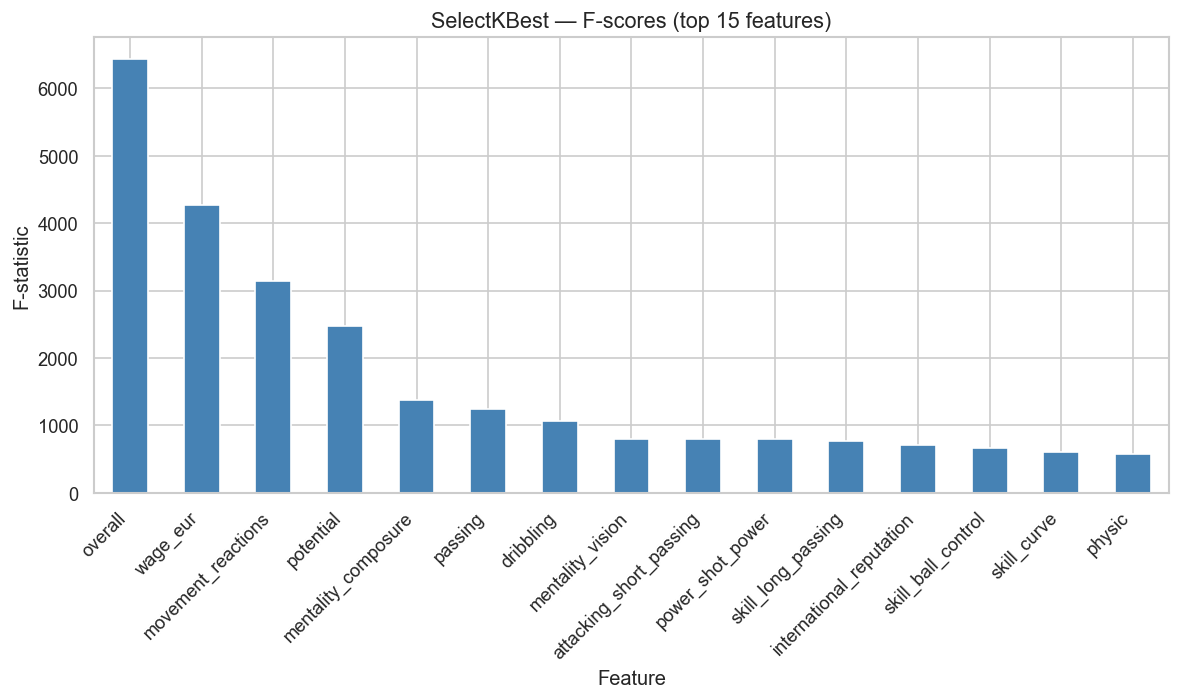

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
kbest_scores.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('SelectKBest — F-scores (top 15 features)', fontsize=13)
ax.set_ylabel('F-statistic')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 6 — Method 2: LASSO Regularization

### What is LASSO?

LASSO (Least Absolute Shrinkage and Selection Operator) is linear regression with an **L1 penalty**:

$$\min \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p}|\beta_j|$$

The penalty term $\alpha \sum|\beta_j|$ forces the model to shrink weak coefficients **to exactly zero** —  
effectively removing those features from the model. The higher the $\alpha$, the more aggressive the pruning.

We use **LassoCV** which automatically finds the optimal $\alpha$ via 5-fold cross-validation.

### Why scale features first?
LASSO penalizes coefficients by their magnitude. If `wage_eur` is in the thousands and `age` is in the tens,  
LASSO would unfairly penalize `wage_eur` more. Scaling to zero-mean, unit-variance puts all features on equal footing.

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(np.abs(lasso.coef_), index=X_imputed.columns)
lasso_coefs = lasso_coefs[lasso_coefs > 0].sort_values(ascending=False)

print(f'Best alpha chosen by LassoCV : {lasso.alpha_:.4f}')
print(f'Features kept (non-zero coef): {len(lasso_coefs)} / {X_imputed.shape[1]}')
print()
print('Top 10 by |coefficient|:')
print(lasso_coefs.head(10).round(4).to_string())

Best alpha chosen by LassoCV : 2630.8695
Features kept (non-zero coef): 43 / 50

Top 10 by |coefficient|:
overall                    1.985498e+06
age                        9.211209e+05
wage_eur                   6.074281e+05
skill_ball_control         4.457130e+05
mentality_composure        2.893841e+05
skill_moves                2.731537e+05
attacking_crossing         2.307446e+05
defending                  2.263317e+05
mentality_interceptions    2.019001e+05
goalkeeping_diving         1.981701e+05


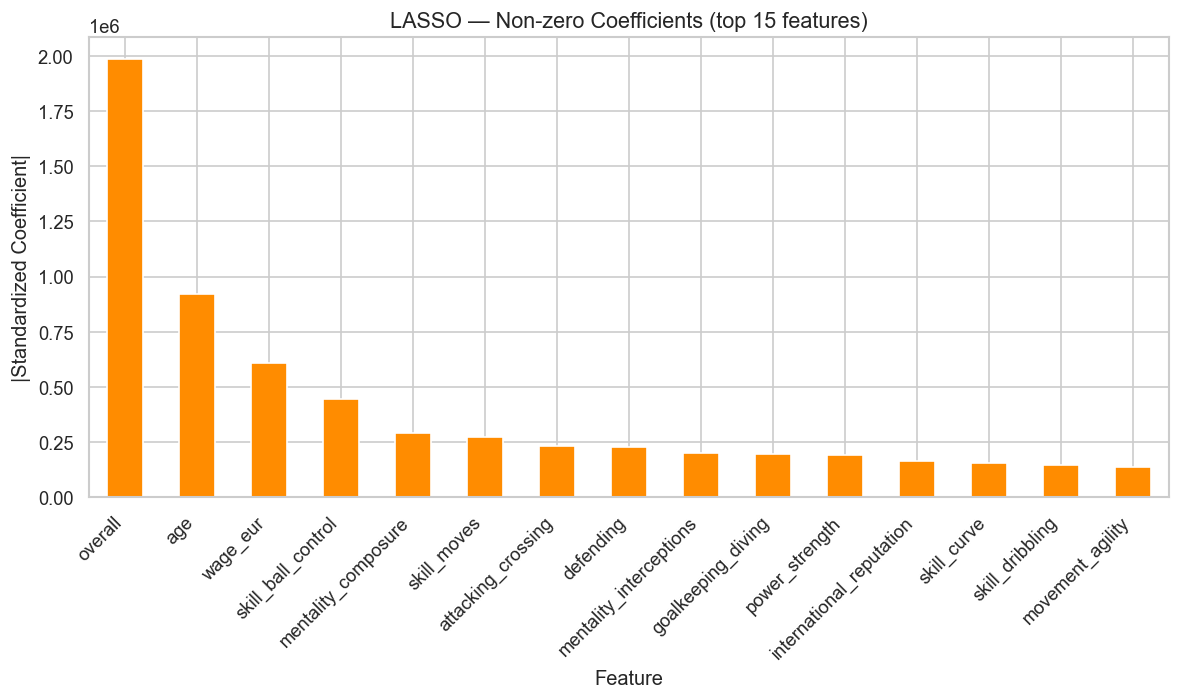

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
lasso_coefs.head(15).plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('LASSO — Non-zero Coefficients (top 15 features)', fontsize=13)
ax.set_ylabel('|Standardized Coefficient|')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 7 — Method 3: Decision Tree Feature Importance

### How does a Decision Tree rank features?

At each node, the tree splits on the feature that most reduces **variance** (for regression).  
Feature importance is the weighted sum of variance reductions across all nodes where the feature was used:

$$\text{importance}(j) = \sum_{\text{nodes using } j} \frac{n_{\text{node}}}{n_{\text{total}}} \cdot \Delta\text{variance}$$

### Advantage over the previous methods
- Captures **non-linear** relationships and **feature interactions**
- Does not assume a linear relationship between feature and target

### Limitation
- A single unconstrained tree can overfit — we limit depth with `max_depth=6` to keep importances stable

In [24]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_imputed, y)

dt_importances = pd.Series(dt.feature_importances_, index=X_imputed.columns)
dt_importances = dt_importances.sort_values(ascending=False)

print('Top 10 features by Decision Tree importance:')
print(dt_importances.head(10).round(4).to_string())

Top 10 features by Decision Tree importance:
overall                     0.7959
potential                   0.1240
age                         0.0387
mentality_composure         0.0292
attacking_volleys           0.0040
wage_eur                    0.0035
movement_reactions          0.0011
mentality_vision            0.0010
shooting                    0.0009
defending_sliding_tackle    0.0008


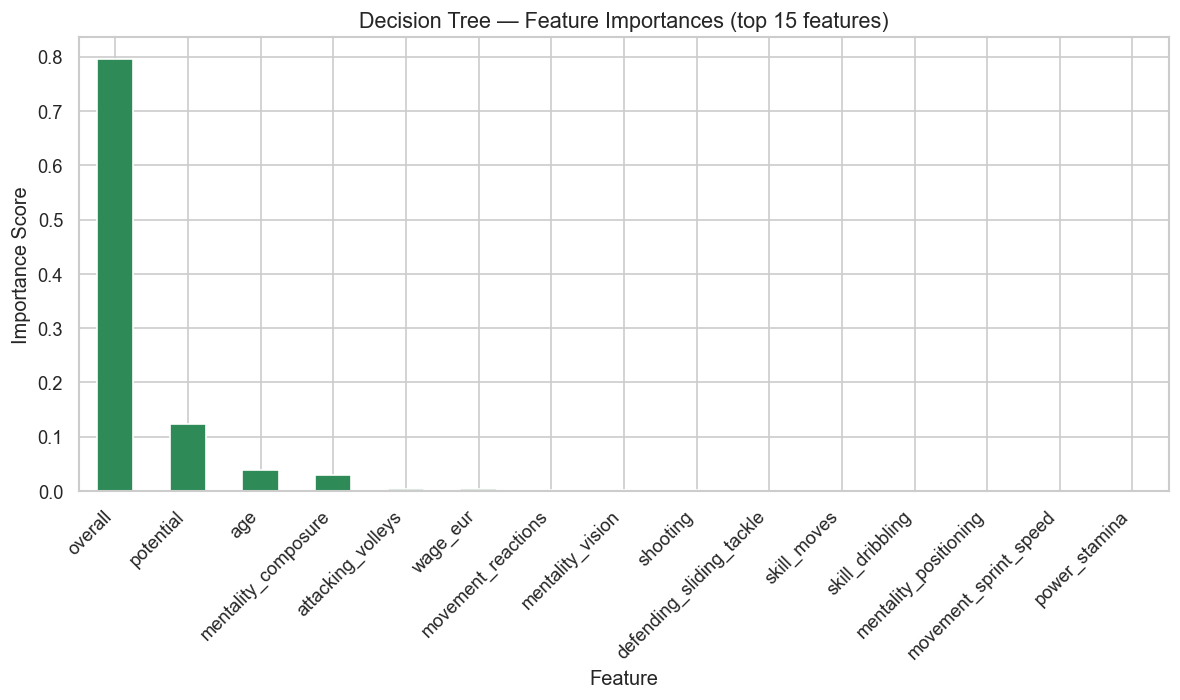

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
dt_importances.head(15).plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Decision Tree — Feature Importances (top 15 features)', fontsize=13)
ax.set_ylabel('Importance Score')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 8 — Aggregate Rankings Across All 3 Methods

Each method produces a different ordering. To find the most **consistently important** features,  
we assign each feature a rank per method (rank 1 = most important) and sum the three ranks.

**Lower combined rank = more consistently important across all methods.**

Features that only score well in one method get penalized by their high ranks in the other two.  
Features that score well in all three rise to the top — these are the most reliable predictors.

In [26]:
# Rank each method (rank 1 = best)
rank_kbest = kbest_scores.rank(ascending=False)

# Features zeroed out by LASSO get the worst rank (= total number of features)
rank_lasso = (lasso_coefs
              .reindex(X_imputed.columns)
              .fillna(0)
              .rank(ascending=False, method='min'))

rank_dt = dt_importances.rank(ascending=False)

# Combined rank: lower is better
combined_rank = (rank_kbest + rank_lasso + rank_dt).sort_values()

print('Combined ranking (lower = more consistently important):')
print(combined_rank.head(10).round(1).to_string())

Combined ranking (lower = more consistently important):
overall                 3.0
wage_eur               11.0
mentality_composure    14.0
potential              32.0
skill_moves            39.0
age                    40.0
skill_dribbling        43.0
skill_ball_control     50.0
movement_reactions     53.0
power_stamina          55.0


In [27]:
# Full comparison table for the top 10
top10 = combined_rank.head(10).index

comparison = pd.DataFrame({
    'KBest Rank'      : rank_kbest[top10].astype(int),
    'LASSO Rank'      : rank_lasso[top10].astype(int),
    'DTree Rank'      : rank_dt[top10].astype(int),
    'Combined Rank'   : combined_rank[top10].astype(int),
    'KBest F-score'   : kbest_scores[top10].round(1),
    'LASSO |coef|'    : lasso_coefs.reindex(top10).fillna(0).round(4),
    'DTree Importance': dt_importances[top10].round(4),
}).sort_values('Combined Rank')

print('Top 10 features — all three methods compared:')
print(comparison.to_string())

Top 10 features — all three methods compared:
                     KBest Rank  LASSO Rank  DTree Rank  Combined Rank  KBest F-score  LASSO |coef|  DTree Importance
overall                       1           1           1              3         6435.6  1.985498e+06            0.7959
wage_eur                      2           3           6             11         4275.1  6.074281e+05            0.0035
mentality_composure           5           5           4             14         1377.0  2.893841e+05            0.0292
potential                     4          26           2             32         2470.2  6.242820e+04            0.1240
skill_moves                  22           6          11             39          441.8  2.731537e+05            0.0005
age                          35           2           3             40          199.1  9.211209e+05            0.0387
skill_dribbling              17          14          12             43          527.0  1.457876e+05            0.0002
skill_ball

## Step 9 — Select the Top 4 Features

We take the 4 features with the lowest combined rank.  
These are the features that **all three methods agree on** as the strongest predictors of `value_eur`.

### Why 4 features?
- Keeps the model interpretable for academic analysis
- Reduces the risk of multicollinearity in the FFNN (notebook 05)
- Each of the 3 downstream notebooks (SEM, clustering, FFNN) benefits from a compact, non-redundant feature set

### Domain justification
| Feature | Domain Meaning |
|---|---|
| `overall` | Best single summary of current ability — directly used by clubs to set transfer prices |
| `wage_eur` | Reflects what the club already pays — a strong market signal of perceived value |
| `movement_reactions` | Reaction time is the most position-agnostic technical skill — valued across all roles |
| `potential` | Clubs pay a premium for upside — young players with high potential fetch higher fees |

In [28]:
top4 = combined_rank.head(4).index.tolist()

print('Selected top 4 features:', top4)
print()

summary = pd.DataFrame({
    'KBest Rank'    : rank_kbest[top4].astype(int),
    'LASSO Rank'    : rank_lasso[top4].astype(int),
    'DTree Rank'    : rank_dt[top4].astype(int),
    'Combined Rank' : combined_rank[top4].astype(int),
}).sort_values('Combined Rank')

print(summary.to_string())

Selected top 4 features: ['overall', 'wage_eur', 'mentality_composure', 'potential']

                     KBest Rank  LASSO Rank  DTree Rank  Combined Rank
overall                       1           1           1              3
wage_eur                      2           3           6             11
mentality_composure           5           5           4             14
potential                     4          26           2             32


## Step 10 — Visualize Top 4 Features vs. Target

Scatter plots with a regression line confirm that the selected features have a **meaningful directional relationship** with `value_eur`.  
The confidence band (shaded region) narrows where data is dense — wider bands at extremes indicate higher uncertainty.

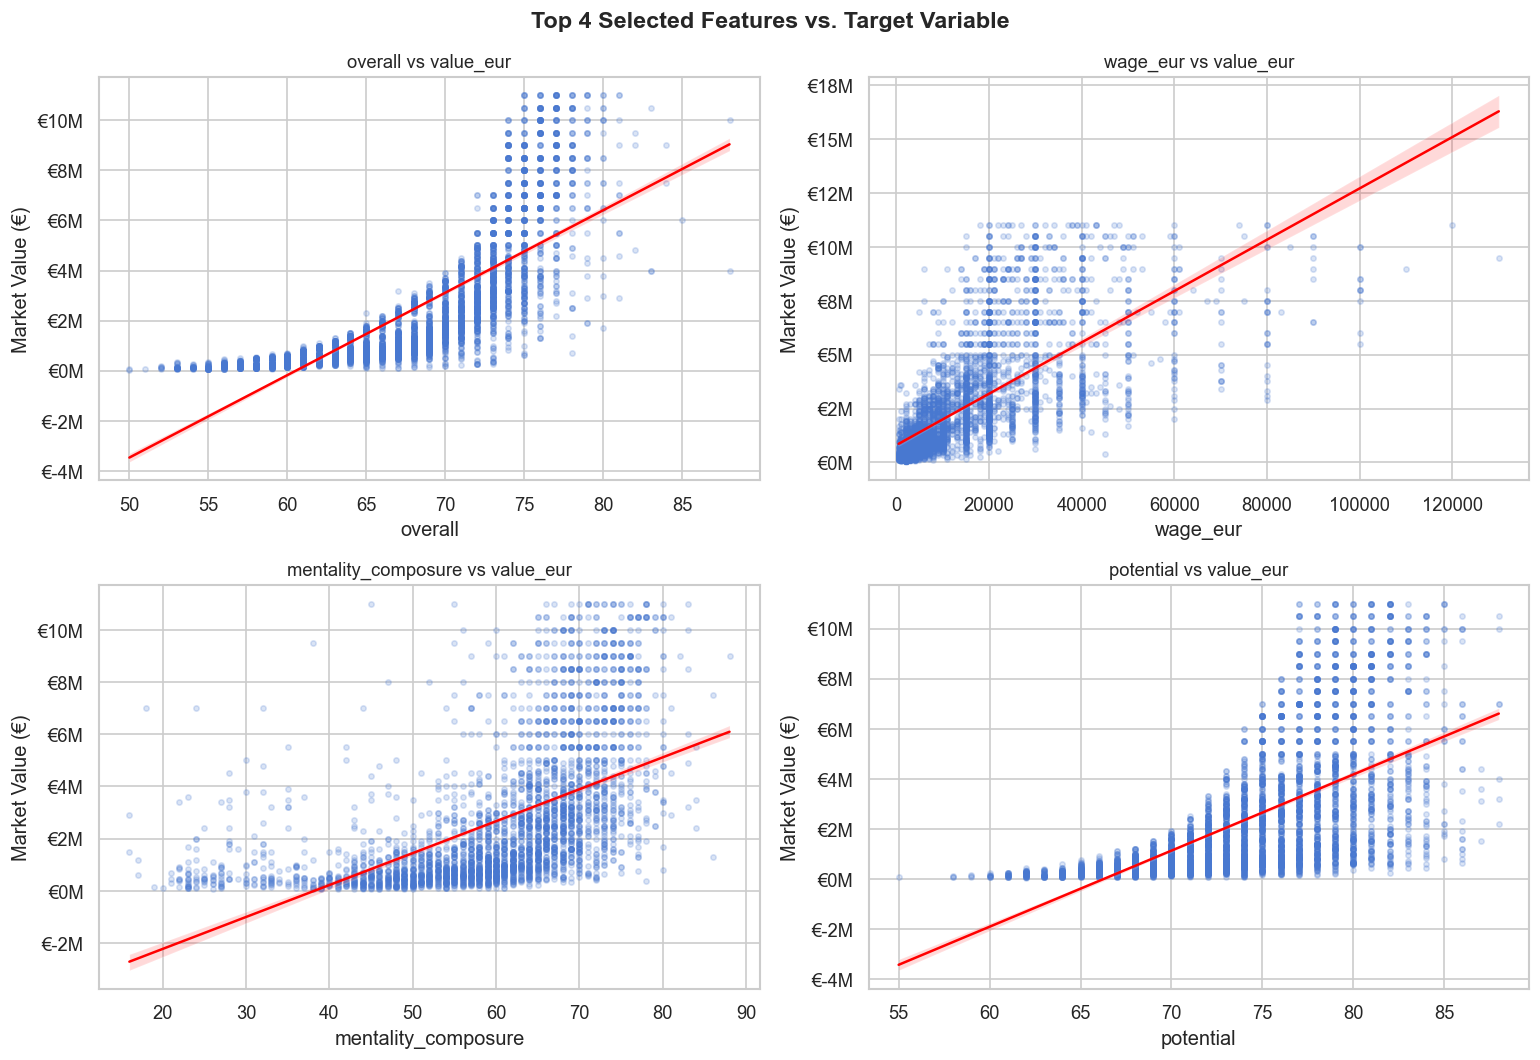

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(top4):
    sns.regplot(
        data=df, x=feat, y='value_eur', ax=axes[i],
        scatter_kws={'alpha': 0.2, 's': 10},
        line_kws={'color': 'red', 'linewidth': 1.5}
    )
    axes[i].set_title(f'{feat} vs value_eur', fontsize=11)
    axes[i].set_ylabel('Market Value (€)')
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M')
    )

plt.suptitle('Top 4 Selected Features vs. Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11 — Save the Feature-Selected Dataset

We save a slim dataset containing only the top 4 features + the target.  
All downstream notebooks (03_sem, 04_clustering, 05_ffnn) will load this file.

In [30]:
output_cols = top4 + ['value_eur']
df_selected = df[output_cols].copy()

output_path = '../data/ligue1_features.csv'
df_selected.to_csv(output_path, index=False)

print(f'Saved to      : {output_path}')
print(f'Shape         : {df_selected.shape}')
print(f'Columns       : {df_selected.columns.tolist()}')
print()
print(df_selected.describe().T.round(2).to_string())

Saved to      : ../data/ligue1_features.csv
Shape         : (4458, 5)
Columns       : ['overall', 'wage_eur', 'mentality_composure', 'potential', 'value_eur']

                      count        mean         std      min       25%        50%        75%         max
overall              4458.0       68.07        6.04     50.0      63.0       69.0       73.0        88.0
wage_eur             4458.0    14057.79    15202.47    500.0    3000.0     9000.0    20000.0    130000.0
mentality_composure  3540.0       60.07       11.85     16.0      54.0       62.0       68.0        88.0
potential            4458.0       74.44        5.08     55.0      71.0       75.0       78.0        88.0
value_eur            4458.0  2479634.37  2589331.20  25000.0  600000.0  1400000.0  3400000.0  11000000.0


---
## Summary — What We Did in This Notebook

| Step | Action | Why |
|------|--------|-----|
| 1 | Loaded `ligue1_clean.csv` | Reproducible starting point from notebook 01 |
| 2 | Dropped identifiers, leakage, and string columns | Prevent biased or meaningless selection |
| 3 | Median-imputed remaining nulls | All three methods require a complete matrix |
| 4 | SelectKBest (F-statistic) | Univariate linear importance |
| 5 | LassoCV | Multivariate regularized importance; auto-tunes alpha via cross-validation |
| 6 | Decision Tree importance | Non-linear, interaction-aware importance |
| 7 | Combined rank aggregation | Consensus — more robust than any single method |
| 8 | Selected top 4 features | Compact, non-redundant set for downstream modeling |
| 9 | Saved `ligue1_features.csv` | Shared input for notebooks 03, 04, 05 |

**Next:** `03_sem.ipynb` — Structural Equation Modeling with 2 latent constructs built from the selected features.